# T11 · How symbolic regression works

Symbolic regression (SR) returns a formula rather than a fitted curve. It is
the only arm in this project that can report a law it was not given, and the
only one whose failure mode is "the law was not in its vocabulary".

This notebook builds SR from its parts, with the small implementation in
`physprior.symbolic`:

1. a formula is a **tree**; its size is its **complexity**;
2. the number of trees grows geometrically with size, so **exhaustive search**
   stops being an option after a handful of nodes;
3. **genetic programming** searches the space instead, keeping the best
   formula at every complexity -- the **Pareto front** -- and picks one with
   PySR's **score**;
4. the **operator set is a prior**: Planck's law is out of reach without `exp`;
5. **SINDy** is the sparse-regression alternative for dynamics, and its weak
   point is the derivative.

The theory, with the measured results, is in `docs/theory/symbolic_regression.md`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


torch 2.11.0


In [2]:
import pandas as pd
from physprior.symbolic.expressions import (
    OperatorSet, bi, un, var, const, evaluate, complexity, to_sympy,
    fit_constants, select, scores, noise_floor)
from physprior.symbolic.enumerate import count_by_size, exhaustive_search
from physprior.symbolic.gp import GPConfig, gp_search
from physprior.symbolic.studies import LAWS, make_data, form_check
from physprior.symbolic import sindy
from physprior.io import load_json, load_table
OPS = OperatorSet()   # + - * /  sqrt square cube exp log: the repo's PySR default
print(OPS.label)

{+, -, *, /, sqrt, square, cube, exp, log}


## 1 · A formula is a tree

Kepler's third law in years and AU is $P = a^{3/2}$. With the operators above
it can be written as `sqrt(cube(a))`: three nodes. The same function also has
longer spellings (`a * sqrt(a)`, four nodes), and a search will meet all of
them. Complexity here is the node count, which is PySR's default.

In [3]:
kepler = un("sqrt", un("cube", var(0)))
alt = bi("*", var(0), un("sqrt", var(0)))
a = np.geomspace(0.39, 5.2, 6)[:, None]
print(to_sympy(kepler, ["a"]), " complexity", complexity(kepler))
print(to_sympy(alt, ["a"]), "   complexity", complexity(alt))
print(evaluate(kepler, a) - evaluate(alt, a))

sqrt(a**3)  complexity 3
a**(3/2)    complexity 4
[-2.77555756e-17  1.11022302e-16  0.00000000e+00  0.00000000e+00
  8.88178420e-16  0.00000000e+00]


Constants are leaves too. A tree fixes the **form**; its constants are then
fitted by ordinary least squares. For Bohr's formula
$\nu = R_H(1 - 1/n^2)$ the form `c1 - c2/square(n)` has two constants and
six nodes, and Levenberg-Marquardt finds both from a start of 1.

In [4]:
x, y, w, _ = make_data(LAWS["bohr"], 12, 0.0, 3)      # tuning seed, noise-free
bohr_form = bi("-", const(), bi("/", const(), un("square", var(0))))
fitted, loss = fit_constants(bohr_form, x[:, None], y, w)
print(to_sympy(fitted, ["n"]), " loss", loss)

1.096776 - 1.096776/n**2  loss 6.986417165465183e-33


## 2 · The search space

With $L$ leaf types, $U$ unary and $B$ binary operators the number of trees
of size $s$ is $T(1)=L$, $T(s) = U\,T(s-1) + B\sum_{i+j=s-1}T(i)T(j)$.
With two leaves (the variable and a constant) and the nine operators above:

In [5]:
counts = count_by_size(15, 2, len(OPS.unary), len(OPS.binary))
print(pd.DataFrame({"size": range(1, 16), "trees": counts}).to_string(index=False))

 size          trees
    1              2
    2             10
    3             66
    4            490
    5           3906
    6          32650
    7         282370
    8        2505450
    9       22679938
   10      208627210
   11     1944557762
   12    18325234410
   13   174313232066
   14  1671440401290
   15 16138835144066


Every tree with a constant needs its own least-squares fit. Exhaustive search
walks the sizes in order and stops at the first size whose best fit reaches
the measurement-noise floor. For the inverse-square law (size 4) that is
instant; for Bohr (size 6) it is ten thousand fits.

In [6]:
for name in ("inverse_square", "bohr"):
    x, y, w, _ = make_data(LAWS[name], 24, 0.0, 3)
    r = exhaustive_search(x[:, None], y, w, ops=OPS, max_size=7,
                          stop_loss=noise_floor(0.0, len(x)))
    print(f"{name:15s} {r.n_evaluated:6d} trees  {r.seconds:5.1f} s  ->",
          select(r.front).expression())
    print(pd.DataFrame(r.history)[["size", "n_trees", "seconds_cum", "best_loss"]]
          .to_string(index=False))

inverse_square     224 trees    0.0 s  -> ((5.930084) / (x0)**2)
 size  n_trees  seconds_cum  best_loss
    1        1     0.000185   0.717198
    2        5     0.000575   0.474539
    3       29     0.003549   0.103470
    4      189     0.029804   0.000000
bohr             10284 trees    3.3 s  -> ((1.096776) - (((1.047271) / x0))**2)
 size  n_trees  seconds_cum    best_loss
    1        1     0.000060 1.692311e+02
    2        5     0.000221 1.862740e+00
    3       29     0.002364 9.762635e-02
    4      189     0.030477 2.751444e-03
    5     1263     0.360737 2.856486e-04
    6     8797     3.330231 1.209138e-32


The committed study repeats this for every law and for a growing vocabulary
(`results/symbolic/time_vs_vocabulary.csv`): each operator added multiplies
the work.

In [7]:
print(load_table("symbolic", "time_vs_vocabulary")[
    ["n_ops", "n_evaluated", "seconds", "expression"]].to_string(index=False))

 n_ops  n_evaluated   seconds                            expression
     5          600  1.728345 ((1.096776) - (((1.047271) / x0))**2)
     6         1201  3.030781 ((1.096776) - (((1.047271) / x0))**2)
     7         2798  7.348058 ((1.096776) - (((1.047271) / x0))**2)
     8         5973 13.370293 ((1.096776) - (((1.047271) / x0))**2)
     9        10284 20.794145 ((1.096776) - (((1.047271) / x0))**2)
    10        19613 33.567673 ((1.096776) - (((1.047271) / x0))**2)
    11        35194 45.866076 ((1.096776) - (((1.047271) / x0))**2)


## 3 · Genetic programming and the Pareto front

GP keeps a population of trees, picks parents by **tournament** (the best of
a few random members, on loss plus a small parsimony penalty), and makes
children by **subtree crossover** and **mutation**. New forms get their
constants fitted. A **hall of fame** holds the best tree at every complexity:
that is the Pareto front, and it is fed back into each generation.

Watch it form on noisy Bohr data (1 % noise, 16 levels, a tuning seed):

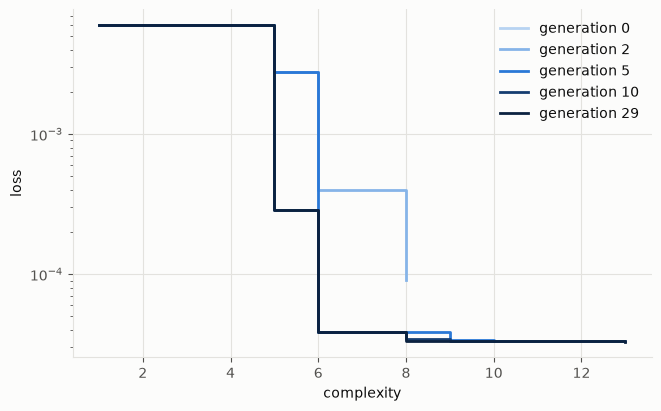

In [8]:
x, y, w, _ = make_data(LAWS["bohr"], 16, 0.01, 7)
parsimony = load_json("symbolic", "tune_gp")["chosen_parsimony"]   # tuned on seeds 3/7/19
res = gp_search(x[:, None], y, w, ops=OPS, seed=7,
                config=GPConfig(generations=30, parsimony=parsimony))
fig, ax = plt.subplots(figsize=(6.5, 4))
gens = [0, 2, 5, 10, len(res.fronts) - 1]
for g, c in zip(gens, ["#b7d3f2", "#86b4e8", "#2a78d6", "#153d70", "#0b2240"]):
    fr = res.fronts[g]
    ax.step([f[0] for f in fr], [f[1] for f in fr], where="post", color=c,
            label=f"generation {g}")
ax.set_yscale("log"); ax.set_xlabel("complexity"); ax.set_ylabel("loss"); ax.legend()
plt.show()

### Choosing one expression

PySR scores each step along the front by
$\text{score}_i = -\Delta\log(\text{loss})/\Delta\text{complexity}$: how
much the loss falls per node added. `model_selection="best"` takes the
highest score among expressions within 1.5x of the lowest loss. A law
shows up as a large drop followed by a flat tail.

In [9]:
tab = pd.DataFrame({"complexity": [c.complexity for c in res.front],
                    "loss": [c.loss for c in res.front],
                    "score": scores(res.front),
                    "expression": [c.expression(["n"]) for c in res.front]})
print(tab.to_string(index=False))
best = select(res.front, "best")
print("\nselected:", best.expression(["n"]))
print(form_check(to_sympy(best.tree), LAWS["bohr"]))

 complexity     loss    score                                                                            expression
          1 0.005987 0.000000                                                                            (1.044061)
          5 0.000286 0.760140                                                     (((-0.5909313) / n) + (1.145217))
          6 0.000039 2.004937                                                  ((1.095678) - ((1.093426) / (n)**2))
          8 0.000034 0.069896                                   ((1.169002) - exp((((3.515289) / n) - (2.818195))))
          9 0.000033 0.001639                           ((2.180558) - exp(((0.06822344) / exp(((-3.001128) / n)))))
         10 0.000033 0.001092                           (sqrt(((1.234016) + ((-1.988517) / n))) + ((0.665799) / n))
         13 0.000033 0.004642 ((1.384563) - ((0.3225702) / ((1.147602) - (((-16.01441) / ((-11.95832) - n)) / n))))

selected: ((1.095678) - ((1.093426) / (n)**2))
{'form_err': 7.346968384

`form_check` asks whether the selected form can represent the exact law on a
grid far beyond the data, and whether its fitted predictions there are within
5 %. With 1 % noise and 16 points, other forms fit the data as well as the
law does; which one is selected is then a property of the data, not of the
search.

## 4 · The vocabulary is a prior

Planck's law $B = x^3/(e^x - 1)$ is seven nodes with `exp`. Without `exp` it
cannot be written at all, and the best any search can do is a curve that
matches inside the data and leaves it outside. This is the repo's H6.

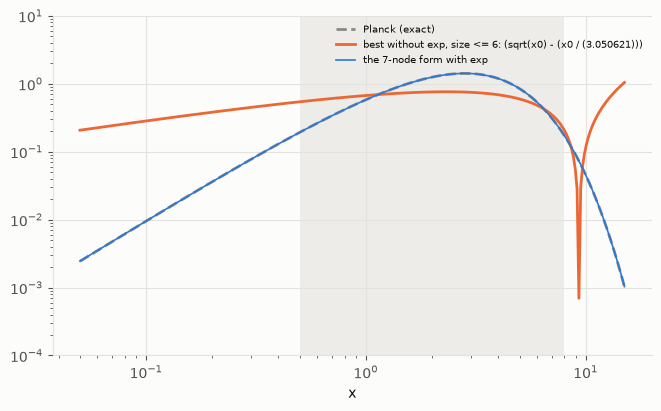

loss without exp: 0.22966611708072682   with exp: 1.0295838239214155e-06


In [10]:
law = LAWS["planck"]
x, y, w, _ = make_data(law, 24, 1e-3, 3)
no_exp = OPS.without("exp", "log")
r = exhaustive_search(x[:, None], y, w, ops=no_exp, max_size=6,
                      stop_loss=noise_floor(1e-3, 24))
best_no_exp = select(r.front)
planck_form = bi("/", un("cube", var(0)), bi("-", un("exp", var(0)), const()))
with_exp, l2 = fit_constants(planck_form, x[:, None], y, w)
xs = np.geomspace(0.05, 15, 300)[:, None]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.axvspan(0.5, 8, color=P.GRID, alpha=0.6, lw=0)
ax.loglog(xs, law.truth(xs[:, 0]), "--", color=P.INK_MUTED, label="Planck (exact)")
ax.loglog(xs, np.abs(evaluate(best_no_exp.tree, xs)), color="#eb6834",
          label=f"best without exp, size <= 6: {best_no_exp.expression()}")
ax.loglog(xs, evaluate(with_exp, xs), color="#2a78d6", lw=1.2, label="the 7-node form with exp")
ax.set_ylim(1e-4, 10); ax.legend(fontsize=7); ax.set_xlabel("x"); plt.show()
print("loss without exp:", best_no_exp.loss, "  with exp:", l2)

The committed study runs the GP, exhaustive search and PySR with and without
`exp` on the same data, over the reporting seeds:

In [11]:
v = load_table("symbolic", "vocabulary")
print(v[["vocabulary", "method", "seed", "recovered", "form_err", "extrap_dev",
         "expression"]].to_string(index=False))

 vocabulary     method  seed  recovered     form_err    extrap_dev                                                                       expression
without exp         gp    11      False 8.542000e-01    977.300204  (((-0.001318459) * ((((x0 + (-8.271056)))**2 + (-29.58761)))**2) - (-1.334635))
without exp exhaustive    11      False 3.194096e+01   3152.026393                                      ((1.185364) - ((sqrt(x0) - (1.766197)))**2)
without exp       pysr    11      False 4.601447e-01  31801.831261 (1.09574495207598*sqrt(x0) - 0.3622823*x0 + 0.36190798992764 - 0.24264447/x0)**3
without exp         gp    23      False 5.196850e-01   2287.386574                ((((-0.4049619) + x0) * (-0.001403682)) * ((x0 - (10.13394)))**3)
without exp       pysr    23      False 5.854071e+01  17615.717347                                   sqrt((-0.14613834*x0**2 + x0 - 0.30673623)**2)
without exp         gp    42      False 9.563258e-01 101415.504187            (x0 * ((0.02551713) - (((-0.012285

## 5 · SINDy: sparse regression for dynamics

For a trajectory, SINDy fixes a library of terms
$\Theta(X) = [1, \theta, \omega, \theta^2, \ldots, \sin\theta, \cos\theta]$ and
solves $\dot X = \Theta(X)\,\Xi$ with sequentially thresholded least squares.
The library plays the role of the operator set. $\dot X$ is not measured:
it has to be estimated, and a finite difference divides the noise by the
step.

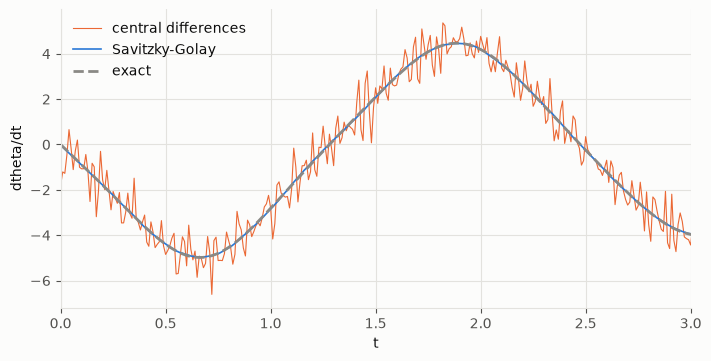

fd {'support_ok': False, 'coef_rel_err': 0.09922490864178587, 'n_extra': 4, 'n_missing': 0}
    dtheta/dt = +1 omega
    domega/dt = -0.635 1 +0.1364 theta -0.1998 omega +0.2693 theta*theta -9.973 sin(theta) +0.6596 cos(theta)
savgol {'support_ok': False, 'coef_rel_err': 0.020393294946263383, 'n_extra': 0, 'n_missing': 1}
    dtheta/dt = +1.001 omega
    domega/dt = -9.786 sin(theta)


In [12]:
sys_ = sindy.pendulum()
t, X = sindy.simulate(sys_)
Xn = sindy.add_noise(X, 0.01, np.random.default_rng(3))
dt = t[1] - t[0]
_, d_fd = sindy.derivative(Xn, dt, "fd")
_, d_sg = sindy.derivative(Xn, dt, "savgol", window=51)
exact = np.array([sys_.rhs(0, s) for s in X])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t, d_fd[:, 0], color="#eb6834", lw=0.8, label="central differences")
ax.plot(t, d_sg[:, 0], color="#2a78d6", lw=1.2, label="Savitzky-Golay")
ax.plot(t, exact[:, 0], "--", color=P.INK_MUTED, label="exact")
ax.set_xlim(0, 3); ax.set_xlabel("t"); ax.set_ylabel("dtheta/dt"); ax.legend(); plt.show()
# threshold and window as chosen on the tuning seeds by the committed study
chosen = {c["method"]: c for c in load_json("symbolic", "sindy_chosen")["chosen"]
          if c["system"] == "pendulum"}
for method in ("fd", "savgol"):
    c = chosen[method]
    m = sindy.fit_sindy(t, Xn, sys_.state, threshold=c["threshold"], method=method,
                        window=int(c["window"]) or 21, trig=True)
    print(method, sindy.score_model(m, sys_))
    print("   ", "\n    ".join(m.equations()))

The threshold and window are the ones the committed study chose on seeds
3/7/19; its results on seeds 11/23/42 are in `results/symbolic/sindy_recovery.csv`.

The printed coefficients show the threshold's dilemma. The pendulum's damping
term is small (b = 0.2, against g/L = 9.8 for the restoring term). A
threshold low enough to keep it also keeps spurious terms that noise in the
states creates; one high enough to reject those can drop it. STLSQ has one
threshold for all terms, so a law with terms of very different sizes is the
hard case for it.

## 6 · AI Feynman, in one line

Udrescu & Tegmark (2020) attack the same problem differently: they fit a
neural network first, then use it to test for symmetries and separability
(does $f(x,y)$ split into $g(x)+h(y)$?), and recursively break the problem
into smaller ones before any brute-force search. It trades the tree search
for tests on a smooth surrogate.

## What to take away

- SR searches a space that grows geometrically; every practical method is a
  heuristic over it, and all of them share the Pareto front as their output.
- The formula it returns is chosen by a rule (the score), and with noise
  several forms fit equally well.
- Nothing outside the operator set can be found. The vocabulary is a prior,
  and should be stated wherever SR results are.